In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

# `loan_status` 
   - 0 = Not Defaulter
   - 1 = defaulter

In [2]:
df = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\Datasets\Modelling_data2.csv')

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230288 entries, 0 to 230287
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loan_amnt                    230288 non-null  int64  
 1   funded_amnt                  230288 non-null  int64  
 2   funded_amnt_inv              230288 non-null  float64
 3   term                         230288 non-null  object 
 4   int_rate                     230288 non-null  float64
 5   installment                  230288 non-null  float64
 6   grade                        230288 non-null  object 
 7   sub_grade                    230288 non-null  object 
 8   emp_length                   230288 non-null  object 
 9   home_ownership               230288 non-null  object 
 10  annual_inc                   230288 non-null  float64
 11  verification_status          230288 non-null  object 
 12  loan_status                  230288 non-null  int64  
 13 

In [4]:
## Inputting the month since last major derogatory equals zero for all the nents because it means that the person has never been accused for any negative remark
df.mths_since_last_major_derog = df.mths_since_last_major_derog.fillna(0)

In [5]:
print(df.head().to_string())

   loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade emp_length home_ownership  annual_inc verification_status  loan_status         purpose    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc  mths_since_last_major_derog application_type
0       5000         5000           4975.0   36 months     10.65       162.87     B        B2  10+ years           RENT     24000.0            Verified            0     credit_card  27.65          0.0           Jan-85             1.0                     0.0                     0.0       3.0      0.0      13648        83.7        9.0                          0.0       INDIVIDUAL
1       2500         2500           2500.0   60 months     15.27        59.83     C        C4   < 1 year           RENT     30000.0     Source Verified            1             car   1.00          0.0           Apr-99             5.0     

In [6]:
# Removing the funded amount features because it occurs after the loan is approved
df = df.drop(['funded_amnt','funded_amnt_inv'],axis= 1)

In [7]:
print(df.head().to_string())

   loan_amnt        term  int_rate  installment grade sub_grade emp_length home_ownership  annual_inc verification_status  loan_status         purpose    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc  mths_since_last_major_derog application_type
0       5000   36 months     10.65       162.87     B        B2  10+ years           RENT     24000.0            Verified            0     credit_card  27.65          0.0           Jan-85             1.0                     0.0                     0.0       3.0      0.0      13648        83.7        9.0                          0.0       INDIVIDUAL
1       2500   60 months     15.27        59.83     C        C4   < 1 year           RENT     30000.0     Source Verified            1             car   1.00          0.0           Apr-99             5.0                     0.0                     0.0       3.0      0.0       1687         9.4     

# Separating ordinal and nominal categories
 - `ordinal_cat` = ['term','grade','sub_grade','emp_length']
 - `nominal_cat` = ['home_ownership','verification_status','purpose','application_type']

In [8]:
# Let us treat the purpose column since it has too many categories categorizing into some main categories
df.purpose.value_counts()

purpose
debt_consolidation    133679
credit_card            46001
home_improvement       13415
other                  13229
major_purchase          5832
small_business          4632
car                     3448
medical                 2627
wedding                 1996
moving                  1841
house                   1494
vacation                1423
educational              419
renewable_energy         252
Name: count, dtype: int64

In [9]:
purpose_map = {
    'debt_consolidation': 'Debt Management',
    'credit_card': 'Debt Management',

    'home_improvement': 'Home & Property',
    'house': 'Home & Property',
    'moving': 'Home & Property',

    'medical': 'Personal Expenses',
    'vacation': 'Personal Expenses',
    'wedding': 'Personal Expenses',
    'other': 'Personal Expenses',

    'small_business': 'Business & Education',
    'educational': 'Business & Education',
    'renewable_energy': 'Business & Education',

    'car': 'Vehicle & Major Purchases',
    'major_purchase': 'Vehicle & Major Purchases'
}

df['purpose_group'] = df['purpose'].map(purpose_map)

In [10]:
df.home_ownership.unique()
df.loc[:,'home_ownership'][df.home_ownership.isin(['OTHER', 'NONE', 'ANY'])] = 'UNSPECIFIED'

C:\Users\Dev\AppData\Local\Temp\ipykernel_14624\1898744161.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.loc[:,'home_ownership'][df.home_ownership.isin(['OTHER', 'NONE', 'ANY'])] = 'UNSPECIFIED'
C:\Users\Dev\AppData\Local\Temp\ipyke

# Separating ordinal and nominal categories
 - `ordinal_cat` = ['term','grade','sub_grade','emp_length']
 - `nominal_cat` = ['home_ownership','verification_status','purpose_group','application_type']

In [11]:
ordinal_cat = ['term','grade','sub_grade','emp_length']
nominal_cat = ['home_ownership','verification_status','purpose_group','application_type']

In [12]:
df = df.drop('purpose',axis = 1)

# Checking whether catgorial varibales are associated with target variable or not
 - # using `Chi-Square test`
    - Categorical Data: Both variables must be nominal or ordinal scales.
    - Independent Observations: No relationship exists between the subjects across the groups.
    - Mutually Exclusive: Each subject fits into exactly one cell in the table.
    - Raw Frequencies: Data must be actual counts, never percentages or means.
    - Large Sample:  At least 80% of expected cell counts must be 5 or more.

 - ### Hypothesis
    - `Ho: Both attributes are independent`
    - `H1: Not`

In [13]:
import scipy.stats as st

def association_test(data,column_one, column_two):
    '''Just give the dataframe and column names'''
        
    obs_freq = pd.crosstab(index = data[column_one], columns = data[column_two])
    chi_test = st.chi2_contingency(observed = obs_freq)

    if chi_test[1] < 0.05:
        return print(f"Test statistics values : {chi_test[0]}\nand p-value is : {chi_test[1]:.3}\nReject Ho:----\n`{column_one}` & `loan_status` attributes are dependent")
    else:
        return print(f'Test statistics values : {chi_test[0]}\nand p-value is : {chi_test[1]:.3}\nFail to Reject Ho:----\n`{column_one}` & `loan_status`  are independent')

In [14]:
# Checking Ordinal columns 
for i in ordinal_cat:
    print(f'-----------------Column1 = {i}, Column2 = loan_status-------------------')
    association_test(data=df, column_one=i, column_two='loan_status')
    print(f'------------------------------------------------------------------------\n\n\n')

-----------------Column1 = term, Column2 = loan_status-------------------
Test statistics values : 6159.462291506341
and p-value is : 0.0
Reject Ho:----
`term` & `loan_status` attributes are dependent
------------------------------------------------------------------------



-----------------Column1 = grade, Column2 = loan_status-------------------
Test statistics values : 13023.027874714417
and p-value is : 0.0
Reject Ho:----
`grade` & `loan_status` attributes are dependent
------------------------------------------------------------------------



-----------------Column1 = sub_grade, Column2 = loan_status-------------------
Test statistics values : 13706.420342111027
and p-value is : 0.0
Reject Ho:----
`sub_grade` & `loan_status` attributes are dependent
------------------------------------------------------------------------



-----------------Column1 = emp_length, Column2 = loan_status-------------------
Test statistics values : 424.6755835217084
and p-value is : 3.51e-84
Reject

# Hence all ordinal categories are important

In [15]:
# Checking nominal columns 
for i in nominal_cat:
    print(f'-----------------Column1 = {i}, Column2 = loan_status-------------------')
    association_test(data=df, column_one=i, column_two='loan_status')
    print(f'------------------------------------------------------------------------\n\n\n')

-----------------Column1 = home_ownership, Column2 = loan_status-------------------
Test statistics values : 526.8924428725433
and p-value is : 7.09e-114
Reject Ho:----
`home_ownership` & `loan_status` attributes are dependent
------------------------------------------------------------------------



-----------------Column1 = verification_status, Column2 = loan_status-------------------
Test statistics values : 1318.8266622181675
and p-value is : 4.17e-287
Reject Ho:----
`verification_status` & `loan_status` attributes are dependent
------------------------------------------------------------------------



-----------------Column1 = purpose_group, Column2 = loan_status-------------------
Test statistics values : 562.0917421272021
and p-value is : 2.48e-120
Reject Ho:----
`purpose_group` & `loan_status` attributes are dependent
------------------------------------------------------------------------



-----------------Column1 = application_type, Column2 = loan_status----------------

# Removing `application_type` column 

In [16]:
df = df.drop('application_type',axis =1 )

# Checking dependancy of numeric columns towards loan_status

In [17]:
print(df.head().to_string())

   loan_amnt        term  int_rate  installment grade sub_grade emp_length home_ownership  annual_inc verification_status  loan_status    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc  mths_since_last_major_derog              purpose_group
0       5000   36 months     10.65       162.87     B        B2  10+ years           RENT     24000.0            Verified            0  27.65          0.0           Jan-85             1.0                     0.0                     0.0       3.0      0.0      13648        83.7        9.0                          0.0            Debt Management
1       2500   60 months     15.27        59.83     C        C4   < 1 year           RENT     30000.0     Source Verified            1   1.00          0.0           Apr-99             5.0                     0.0                     0.0       3.0      0.0       1687         9.4        4.0                      

# Checking association of numerical columns with the target variable by using 
 - `Independent T test` or 
 - `man Whitney test`

 ### Two-sample t-test (numeric vs binary target)

#### Original Statistical Hypothesis
* **$H_0: \mu_1 = \mu_2$** $\rightarrow$ The group means are equal.
* **$H_1: \mu_1 \neq \mu_2$** $\rightarrow$ The group means differ.

#### Converted Association Hypothesis
* **$H_0$:** The numeric variable is independent with the binary target (no difference in means).
* **$H_1$:** The numeric variable is associated with the binary target (means differ between groups).

***

### Mann–Whitney U test (numeric vs binary target)

#### Original Statistical Hypothesis
* **$H_0$:** The two groups come from the same distribution .
* **$H_1$:** The two groups come from different distributions.

#### Converted Association Hypothesis
* **$H_0$:** The numeric variable is independent with the binary target (distributions are the same).
* **$H_1$:** The numeric variable is associated with the binary target (distributions differ between groups).


### Anderson–Darling test (for large samples)

#### Original Statistical Hypothesis
* **$H_0$:** The sample data follows a specified distribution (typically normal).
* **$H_1$:** The sample data does not follow the specified distribution.
#### Decision Rule
* **Compare $A^2$ to critical values**: Reject $H_0$ if the test statistic is greater than the critical value at your chosen significance level (e.g., $\alpha = 0.05$).
* **Reject $H_0$ ($A^2 > \text{Critical Value}$)**: The numeric variable is significantly different from the specified distribution (not normal).
* **Fail to reject $H_0$ ($A^2 \le \text{Critical Value}$)**: There is not enough evidence to say the variable deviates from the specified distribution (assume normal).



## Statistical Justification for Feature Selection

### Why T-Test / Mann-Whitney for Numerical Features?

#### The Core Logic

If a numerical feature is **independent** of the target (`loan_status`), then:
- The distribution of that feature should look **identical** in both groups
- The mean/median of defaulters should be **no different** from non-defaulters
- Knowing the value of that feature tells you **nothing** about whether
  someone defaults

If a numerical feature is **associated** with the target (`loan_status`), then:
- The distribution of that feature should look **different** across the two groups
- The mean/median of defaulters should be **significantly different** from
  non-defaulters
- Knowing the value of that feature **changes** the probability of default

> Therefore — a statistically significant difference in distribution between
> the two target classes is evidence of association, which is a necessary
> condition for a feature to have predictive value in a classification model.

---

#### The Population Interpretation — Simple Version

Think of it this way:

- **Defaulters** = Population 1
- **Not Defaulters** = Population 2

We are asking: *"Do these two populations come from the same distribution
for this feature?"*

- If **yes** (same distribution) → feature behaves identically in both
  groups → feature is **independent** of default → no predictive value → **Drop**
- If **no** (different distributions) → feature behaves differently across
  groups → feature is **associated** with default → has predictive value → **Keep**

T-Test and Mann-Whitney are simply the statistical tools that answer
this population comparison question formally — with a p-value that
tells us how confident we can be in that answer.

---

#### Important Clarification

T-Test and Mann-Whitney **do not directly test dependence or independence.**
What they test is:

> *"Is the distribution of this numerical variable significantly different
> between Defaulters and Not Defaulters?"*

We use this as a **proxy for association** because:
- Independent feature → identical distributions → test non-significant
- Associated feature → different distributions → test significant

This is consistent with how association is defined in predictive modelling —
a feature is considered associated with the target if its values
**behave differently** across target classes.

---

#### Why Not a Direct Dependence Test?

The formal test for dependence between a numerical and categorical variable
would be **Point Biserial Correlation** or **ANOVA**. However:

- **T-Test is mathematically equivalent to ANOVA** for two groups
- **Mann-Whitney is the non-parametric equivalent** when normality fails
- Both are **widely accepted in statistical literature** for this exact
  use case — numerical feature vs binary target association testing

---

#### Why Anderson-Darling First?

Before choosing T-Test or Mann-Whitney, we need to know whether the
numerical column follows a **normal distribution** — because T-Test
assumes normality. If that assumption is violated, T-Test gives
unreliable results.

- **Anderson-Darling rejects normality** →
  use **Mann-Whitney** (no normality assumption)
- **Anderson-Darling fails to reject normality** →
  use **T-Test**

Most financial variables in this dataset (annual income, DTI, revolving
utilization) are right-skewed and non-normal — so Mann-Whitney is the
dominant choice throughout this analysis.

---

#### Decision Rule

$$p\text{-value} < \alpha = 0.05 \Rightarrow \text{Reject } H_0
\Rightarrow \text{Two populations differ}
\Rightarrow \text{Feature associated with target}
\Rightarrow \textbf{Keep}$$

$$p\text{-value} \geq \alpha = 0.05 \Rightarrow \text{Fail to reject } H_0
\Rightarrow \text{Two populations same}
\Rightarrow \text{Feature independent of target}
\Rightarrow \textbf{Drop}$$


In [18]:
num_columns = ['loan_amnt','int_rate','installment','annual_inc','dti','revol_bal','revol_util']

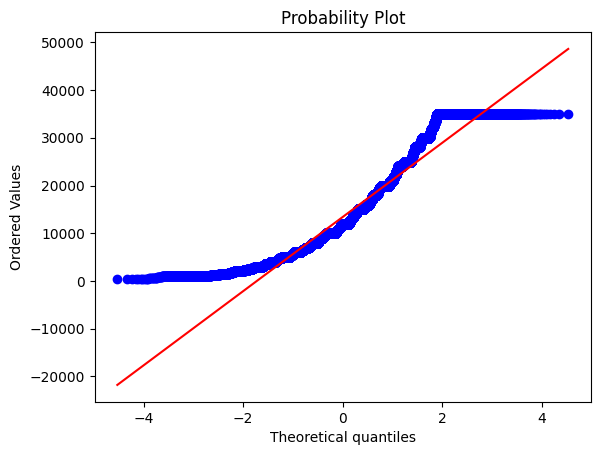

In [19]:
df[num_columns[0]]
st.probplot(df[num_columns[0]], plot = plt)
plt.show()


In [20]:

# Anderson Darling test + probplot (for normality )

def normality_test(data ,column):
    print(f'------------------{column}------------------')
    ''' It checks whether the data comes from a normal population or not\nby using probplot and Anderson darling test'''

    plt.figure(figsize=(3,2))
    st.probplot(df[column], plot = plt)
    plt.show()

    A2 = st.anderson(df[column])[0]
    critical_val = st.anderson(df[column])[1][2]      # critical value at 5% los 

    if A2 > critical_val:
        return print(f'A2 = {A2}\nFor 5% los critical value = {critical_val}\nReject Ho: {column} does not comes from normal popn')

   
    else:
        return print(f'A2 = {A2}\nFor 5% los critical value = {critical_val}\nFail to Reject Ho: {column} comes from normal popn')

------------------loan_amnt------------------


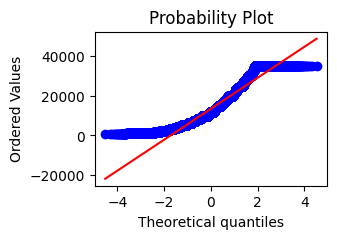

A2 = 4062.6126260370947
For 5% los critical value = 0.787
Reject Ho: loan_amnt does not comes from normal popn


In [21]:
normality_test(data = df , column = 'loan_amnt')

In [22]:
# non parametric test for association 
def non_parametric_t_test_for_association(data,col1):

    ''' This uses man whitney U test for checking weather two groups are independent '''
    g1 = df[col1][df['loan_status'] == 0 ]
    g2 = df[col1][df['loan_status'] == 1 ]
    test = st.mannwhitneyu(g1,g2)
    if test[1] < 0.05:
        print(f'Reject H0: {col1} is associated with loan_status')
    else:
        print(f'Fail to Reject H0: {col1} is independent with loan_status')


# parametric test for association 
def parametric_t_test_for_association(data,col1):

    ''' This uses man whitney U test for checking weather two groups are independent '''
    g1 = df[col1][df['loan_status'] == 0 ]
    g2 = df[col1][df['loan_status'] == 1 ]
    test = st.ttest_ind(g1,g2)
    if test[1] < 0.05:
        print(f'Reject H0: {col1} is associated with loan_status')
    else:
        print(f'Fail to Reject H0: {col1} is independent with loan_status')

# Checking whether numeric columns belong to normal family or not

------------------loan_amnt------------------


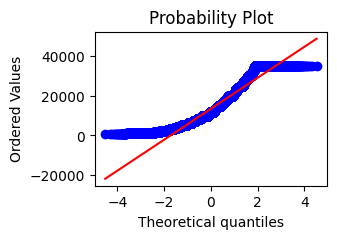

A2 = 4062.6126260370947
For 5% los critical value = 0.787
Reject Ho: loan_amnt does not comes from normal popn

------------------int_rate------------------


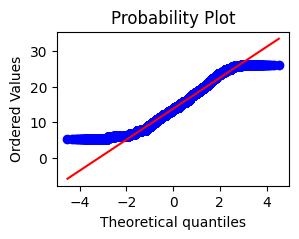

A2 = 580.6598406772537
For 5% los critical value = 0.787
Reject Ho: int_rate does not comes from normal popn

------------------installment------------------


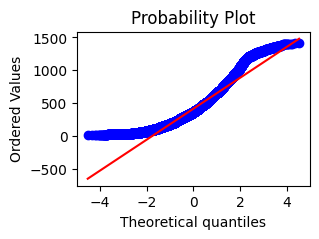

A2 = 3700.7686928659386
For 5% los critical value = 0.787
Reject Ho: installment does not comes from normal popn

------------------annual_inc------------------


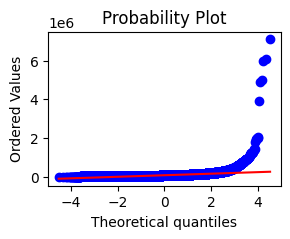

A2 = 14953.28832373902
For 5% los critical value = 0.787
Reject Ho: annual_inc does not comes from normal popn

------------------dti------------------


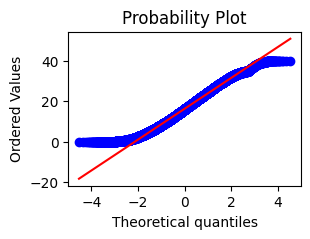

A2 = 346.9557309183292
For 5% los critical value = 0.787
Reject Ho: dti does not comes from normal popn

------------------revol_bal------------------


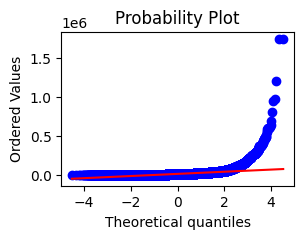

A2 = 19694.844561523147
For 5% los critical value = 0.787
Reject Ho: revol_bal does not comes from normal popn

------------------revol_util------------------


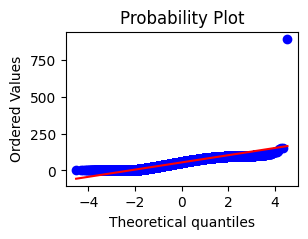

A2 = 1010.0991489010339
For 5% los critical value = 0.787
Reject Ho: revol_util does not comes from normal popn



In [23]:
for i in num_columns:
    normality_test(data = df, column=i)
    print()

# All numeric columns come from population other than normal

In [24]:
for i in num_columns:
    non_parametric_t_test_for_association(data = df ,col1 = i)
    print()

Reject H0: loan_amnt is associated with loan_status

Reject H0: int_rate is associated with loan_status

Reject H0: installment is associated with loan_status

Reject H0: annual_inc is associated with loan_status

Reject H0: dti is associated with loan_status

Reject H0: revol_bal is associated with loan_status

Reject H0: revol_util is associated with loan_status



# So each numeric column is associated with target variable

In [25]:
df[num_columns].corr()[df[num_columns].corr() > 0.5]

# Since int rate is highly positive correlated with installment , so removign installment 


,loan_amnt,int_rate,installment,annual_inc,dti,revol_bal,revol_util
loan_amnt,1.000000,NaN,0.955825,NaN,NaN,NaN,NaN
int_rate,NaN,1.0,NaN,NaN,NaN,NaN,NaN
installment,0.955825,NaN,1.000000,NaN,NaN,NaN,NaN
annual_inc,NaN,NaN,NaN,1.0,NaN,NaN,NaN
dti,NaN,NaN,NaN,NaN,1.0,NaN,NaN
revol_bal,NaN,NaN,NaN,NaN,NaN,1.0,NaN
revol_util,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [26]:
df = df.drop('installment',axis=1)

In [27]:
print(df.head().to_string())

   loan_amnt        term  int_rate grade sub_grade emp_length home_ownership  annual_inc verification_status  loan_status    dti  delinq_2yrs earliest_cr_line  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc  mths_since_last_major_derog              purpose_group
0       5000   36 months     10.65     B        B2  10+ years           RENT     24000.0            Verified            0  27.65          0.0           Jan-85             1.0                     0.0                     0.0       3.0      0.0      13648        83.7        9.0                          0.0            Debt Management
1       2500   60 months     15.27     C        C4   < 1 year           RENT     30000.0     Source Verified            1   1.00          0.0           Apr-99             5.0                     0.0                     0.0       3.0      0.0       1687         9.4        4.0                          0.0  Vehicle & Major Purchases
2   

In [28]:
print(ordinal_cat)
print(nominal_cat)
print(df.columns)
print(num_columns)
nominal_cat.remove('application_type')

['term', 'grade', 'sub_grade', 'emp_length']
['home_ownership', 'verification_status', 'purpose_group', 'application_type']
Index(['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'loan_status',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'mths_since_last_major_derog', 'purpose_group'],
      dtype='object')
['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_bal', 'revol_util']


In [29]:
col = ordinal_cat + nominal_cat + num_columns

remaining_col = []
for i in df.columns:
    if i not in col:
        remaining_col.append(i)

In [30]:
df2 = df[remaining_col]

In [31]:
df2.head()

,loan_status,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,total_acc,mths_since_last_major_derog
0,0,0.0,Jan-85,1.0,0.0,0.0,3.0,0.0,9.0,0.0
1,1,0.0,Apr-99,5.0,0.0,0.0,3.0,0.0,4.0,0.0
2,0,0.0,Nov-01,2.0,0.0,0.0,2.0,0.0,10.0,0.0
3,0,0.0,Feb-96,1.0,35.0,0.0,10.0,0.0,37.0,0.0
4,0,0.0,Nov-04,3.0,0.0,0.0,9.0,0.0,12.0,0.0


In [32]:
# delinq_2yrs
df2['delinq_2yrs_flag'] = df2['delinq_2yrs'].clip(0,1)

C:\Users\Dev\AppData\Local\Temp\ipykernel_14624\3830283884.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['delinq_2yrs_flag'] = df2['delinq_2yrs'].clip(0,1)


In [33]:
association_test(data = df2, column_one = 'delinq_2yrs_flag', column_two='loan_status')
df = df.drop('delinq_2yrs',axis = 1)
df2 = df2.drop('delinq_2yrs',axis = 1)

Test statistics values : 66.71696514694054
and p-value is : 3.13e-16
Reject Ho:----
`delinq_2yrs_flag` & `loan_status` attributes are dependent


In [34]:
# inq_last_6mths
df2['inq_last_6mths'].value_counts()
# creating bins 0,1,2,3+
df2['inq_last_6mths_bin'] = pd.cut(df2['inq_last_6mths'].astype(int),bins= [-np.inf,0,1,2,np.inf],labels=['0','0-1','1-2','2+'])

In [35]:
association_test(df2,column_one='inq_last_6mths_bin',column_two='loan_status')
df = df.drop('inq_last_6mths',axis = 1)
df2 = df2.drop('inq_last_6mths',axis = 1)

Test statistics values : 831.0586967208303
and p-value is : 7.95e-180
Reject Ho:----
`inq_last_6mths_bin` & `loan_status` attributes are dependent

In [36]:
# mths_since_last_delinq
df2['mths_since_last_delinq_flag'] = df2.mths_since_last_delinq.clip(0,1)


In [37]:
association_test(data = df2, column_one = 'mths_since_last_delinq_flag', column_two='loan_status')
# So the binary flagged column month since last delinquency is defended to loan status
df = df.drop('mths_since_last_delinq',axis = 1)
df2 = df2.drop('mths_since_last_delinq',axis = 1)

Test statistics values : 12.615879456423393
and p-value is : 0.000382
Reject Ho:----
`mths_since_last_delinq_flag` & `loan_status` attributes are dependent


In [38]:
#  mths_since_last_record
df2.mths_since_last_record.value_counts() # due to majority has no record - converting it inot flag
df2['mths_since_last_record_flag'] = df2.mths_since_last_record.clip(0,1)

In [39]:
association_test(data = df2 , column_one='mths_since_last_record_flag', column_two='loan_status')
df = df.drop('mths_since_last_record',axis = 1)
df2 = df2.drop('mths_since_last_record',axis = 1)


Test statistics values : 11.709899078402174
and p-value is : 0.000622
Reject Ho:----
`mths_since_last_record_flag` & `loan_status` attributes are dependent


In [40]:
# open_acc
np.cumsum(df2.open_acc.value_counts().sort_index()*100/sum(df2.open_acc.value_counts().sort_index()))
# By taking the cumulative sum value counts of open account we can determine the percentage of people below a specific open account number
# We are using this cumulative sum determine bins

open_acc
0.0       0.002171
1.0       0.036476
2.0       0.571458
3.0       2.065240
4.0       5.133138
5.0      10.181599
6.0      17.334381
7.0      25.745588
8.0      35.006600
9.0      44.656257
10.0     53.734020
11.0     62.091381
12.0     69.406569
13.0     75.548009
14.0     80.667686
15.0     84.792955
16.0     88.174373
17.0     90.819322
18.0     92.963593
19.0     94.654954
20.0     95.938564
21.0     96.943827
22.0     97.709824
23.0     98.283020
24.0     98.727246
25.0     99.059873
26.0     99.280466
27.0     99.455030
28.0     99.568367
29.0     99.663031
30.0     99.733812
31.0     99.785052
32.0     99.832818
33.0     99.866689
34.0     99.893177
35.0     99.914889
36.0     99.931824
37.0     99.946589
38.0     99.959182
39.0     99.968735
40.0     99.973946
41.0     99.979591
42.0     99.983065
43.0     99.985670
44.0     99.987407
45.0     99.990013
46.0     99.991749
47.0     99.993486
48.0     99.994355
49.0     99.996092
50.0     99.996960
51.0     99.997395
52.

In [41]:
# bins = 5,7,9,13,17,17+
df2['open_acc_bin'] = pd.cut(df2.open_acc, bins = [-np.inf,0,5,7,9,13,17,np.inf], labels=['0','0-5','5-7','7-9','9-13','13-17','17+'])

In [42]:
association_test(data = df2, column_one='open_acc_bin', column_two='loan_status')
df = df.drop('open_acc',axis = 1)
df2 = df2.drop('open_acc',axis = 1)


Test statistics values : 85.16179285442477
and p-value is : 3.06e-16
Reject Ho:----
`open_acc_bin` & `loan_status` attributes are dependent


In [43]:
# pub_rec
df2.pub_rec.value_counts()
# Since the majority of the borrowers has no public record converting this column into flag
df2['pub_rec_flag'] = df2.pub_rec.clip(0,1)

In [44]:
association_test(data = df2, column_one='pub_rec_flag', column_two= 'loan_status')
df = df.drop('pub_rec',axis = 1)
df2 = df2.drop('pub_rec',axis = 1)


Test statistics values : 11.665791402202032
and p-value is : 0.000637
Reject Ho:----
`pub_rec_flag` & `loan_status` attributes are dependent


In [45]:
# total_acc
counts = df2.total_acc.value_counts().sort_index()
proportions = counts / counts.sum()
cumulative = np.cumsum(proportions)

print((cumulative*100).to_string())
# Using the cumulative table For the total number of borrowers binning it


total_acc
1.0        0.009119
2.0        0.031265
3.0        0.187157
4.0        0.598815
5.0        1.218908
6.0        2.094768
7.0        3.238553
8.0        4.736678
9.0        6.480581
10.0       8.583165
11.0      10.877249
12.0      13.480511
13.0      16.386004
14.0      19.402227
15.0      22.609515
16.0      25.967484
17.0      29.479174
18.0      33.001720
19.0      36.565952
20.0      40.224849
21.0      43.895470
22.0      47.490968
23.0      51.019593
24.0      54.468318
25.0      57.764191
26.0      60.926318
27.0      63.943844
28.0      66.868877
29.0      69.653651
30.0      72.266901
31.0      74.695164
32.0      77.009657
33.0      79.120058
34.0      81.104964
35.0      82.956125
36.0      84.627944
37.0      86.149517
38.0      87.495223
39.0      88.799677
40.0      89.951713
41.0      91.011255
42.0      91.973095
43.0      92.861547
44.0      93.655336
45.0      94.365751
46.0      94.984975
47.0      95.569027
48.0      96.087508
49.0      96.539550
50.0      

In [46]:
# bin = 10,16,20,26,35,35+
df2['total_acc_bin'] = pd.cut(df2['total_acc'], bins = [-np.inf,10,16,20,26,35,np.inf] ,labels = ['0-10','10-16','16-20','20-26','26-35','35+'])

In [47]:
association_test(df2, column_one='total_acc_bin', column_two='loan_status')
df = df.drop('total_acc',axis = 1)
df2 = df2.drop('total_acc',axis = 1)


Test statistics values : 166.35935620670702
and p-value is : 4.36e-34
Reject Ho:----
`total_acc_bin` & `loan_status` attributes are dependent


In [48]:
df2 = df2.drop('mths_since_last_major_derog',axis=1)
df = df.drop('mths_since_last_major_derog',axis=1)

In [49]:
df = pd.concat([df.drop(['loan_status','earliest_cr_line'],axis = 1),df2],axis=1)

In [50]:
df['earliest_cr_line'] = pd.to_datetime('01'+df.earliest_cr_line)

C:\Users\Dev\AppData\Local\Temp\ipykernel_14624\2677614595.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime('01'+df.earliest_cr_line)


In [51]:
print(np.cumsum((df['earliest_cr_line'].dt.year.value_counts().sort_index()*100/len(df))).to_string())

earliest_cr_line
1976      0.217119
1977      0.491993
1978      0.874123
1979      1.244529
1980      1.631870
1981      2.051779
1982      2.606302
1983      3.379681
1984      4.326322
1985      5.366324
1986      6.530953
1987      7.917911
1988      9.551084
1989     11.533384
1990     13.798808
1991     15.951331
1992     18.279719
1993     21.517404
1994     25.697388
1995     30.365890
1996     35.416088
1997     40.645626
1998     46.956420
1999     54.202998
2000     62.261169
2001     69.798687
2002     76.095150
2003     81.448447
2004     86.093500
2005     90.007295
2006     93.649691
2007     96.345446
2008     97.829240
2009     98.475822
2010     98.862294
2011     98.978236
2046     98.978670
2048     98.979104
2050     98.979539
2054     98.981276
2055     98.983013
2056     98.985184
2057     98.985618
2058     98.988223
2059     98.992132
2060     98.999079
2061     99.002988
2062     99.013844
2063     99.030345
2064     99.045977
2065     99.066821
2066     99.09

In [52]:
df = df.drop('earliest_cr_line',axis = 1)

In [53]:
df.to_csv('modelling_ready_data.csv')